# Computer Exercise 6.1 — Problem 3

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **단원**: 6.1 First-Degree Splines — *Runge 함수와 적응적 노드 (knot placement)*
> **풀이 일자**: Day 23
> **언어**: Python 3 (NumPy / Matplotlib)

## 1. 문제 (원문)

> **CE 6.1.3 (style of C&K, Runge experiment).** Interpolate the Runge function
> $f(x) = 1/(1 + 25 x^2)$ on $[-1, 1]$ by the linear spline $S_1$ and by the global Lagrange polynomial
> $p_n$ at the same $n + 1$ equally spaced nodes. Show that as $n$ grows, $p_n$ *diverges* near the endpoints
> (Runge phenomenon) while $S_1$ converges monotonically. Then replace uniform knots with an
> *equidistribution-of-error* adaptive grid and quantify the extra accuracy.

### 한국어 풀이용 정리
1차 spline 은 *지역성* 덕에 어떤 노드 분포에서도 $\mathcal O(h^2)$ 로 수렴한다. 반면 전역 Lagrange 는
$f$ 의 *복소 해석성 영역* 이 Bernstein 타원을 다 덮지 못하면 *발산* 할 수 있다 — Runge 함수
$f(x) = 1/(1 + 25 x^2)$ 가 정확히 그런 사례 ($x = \pm i/5$ 의 극).

이 노트북에서

1. spline 의 *수렴* 과 Lagrange 의 *발산* 을 *같은 노드* 위에서 정면 비교.
2. *적응적 노드* — $|f''|$ 가 큰 곳에 노드를 더 박는 단순한 규칙 — 가 spline 정확도를 얼마나 끌어올리는지 측정.

## 2. 수학적 배경

### 2.1 Runge 함수와 전역 다항식
$f(x) = 1/(1 + 25 x^2)$ 는 복소평면에서 $\pm i/5$ 에 단순극을 갖는다. Bernstein 타원의 *반경* 이 이 극보다
크면 균등 노드 Lagrange 가 발산한다 — $|p_n - f|_\infty \to \infty$.

대비:

$$
\|f - S_1\|_\infty \;\le\; \frac{h^2}{8}\,\max_x |f''(x)| \;\xrightarrow{n \to \infty}\; 0.
$$

### 2.2 *Equidistribution of error* — 적응적 노드 규칙
지역 오차의 상한이 *각 구간 $[t_{i-1}, t_i]$* 에서

$$
E_i \;\le\; \frac{h_i^2}{8}\,\max_{x \in [t_{i-1}, t_i]}|f''(x)|
$$

이므로, 모든 $E_i$ 를 *같게* 만들면 $\max E_i$ 가 최소가 된다 (등배분 원리). 그 조건은

$$
h_i^2\,|f''|_i \;=\; \text{const}.
$$

밀도 $\rho(x) \propto |f''(x)|^{1/2}$ 의 *누적분포* 를 $n$ 등분하는 노드를 만들면 된다.

## 3. 풀이 흐름

1. $f$, $f''$ 정의.
2. 균등 노드에서 $n = 4, 8, 16, 32, 64$ 에 대해 $S_1$ 과 Lagrange $p_n$ 의 최대 오차 측정 (dense 격자 8001 점).
3. loglog: $S_1$ 은 기울기 $+2$, $p_n$ 은 *기울기가 음수* (발산) 임을 확인.
4. 한 케이스 ($n = 16$) 의 시각적 비교 — $p_n$ 의 *끝점 진동* 과 $S_1$ 의 *조용한 정확성*.
5. **적응 노드**: $\rho(x) = \sqrt{|f''(x)|}$ 의 CDF 를 만든 뒤 균등 분위수 $i/n$ 으로 inverse-CDF 하여 노드 $t_i$ 생성.
6. 같은 $n$ 에서 *균등 vs 적응* spline 의 최대 오차 비교.
7. 적응 노드가 *어디에 모이는지* — 단순한 *밀도 시각화* 로 직관 확인.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Runge function ---
a, b = -1.0, 1.0
f    = lambda x: 1.0 / (1.0 + 25.0 * x * x)
fpp  = lambda x: 50.0 * (75.0 * x * x - 1.0) / (1.0 + 25.0 * x * x) ** 3   # f''(x)

def S1(t, y, x):
    x = np.asarray(x, dtype=float)
    idx = np.searchsorted(t, x) - 1
    idx = np.clip(idx, 0, len(t) - 2)
    x0, x1 = t[idx], t[idx + 1]
    y0, y1 = y[idx], y[idx + 1]
    return y0 + (y1 - y0) * (x - x0) / (x1 - x0)

X = np.linspace(a, b, 8001)
fX = f(X)

ns = [4, 8, 16, 32, 64, 128]
E_S1, E_pn = [], []
for n in ns:
    t = np.linspace(a, b, n + 1)
    y = f(t)
    E_S1.append(np.max(np.abs(fX - S1(t, y, X))))
    coefs = np.polyfit(t, y, n)
    E_pn.append(np.max(np.abs(fX - np.polyval(coefs, X))))

h = (b - a) / np.array(ns)

df = pd.DataFrame({
    "n"            : ns,
    "h"            : h,
    "E_S1 (uniform)": E_S1,
    "ratio (S1)"   : [np.nan] + list(np.array(E_S1[:-1]) / np.array(E_S1[1:])),
    "E_Lagrange"   : E_pn,
})
pd.set_option("display.float_format", lambda v: f"{v:.4e}")
df

/tmp/ipykernel_8/3740722637.py:27: RankWarning: Polyfit may be poorly conditioned
  coefs = np.polyfit(t, y, n)
/tmp/ipykernel_8/3740722637.py:27: RankWarning: Polyfit may be poorly conditioned
  coefs = np.polyfit(t, y, n)
/tmp/ipykernel_8/3740722637.py:27: RankWarning: Polyfit may be poorly conditioned
  coefs = np.polyfit(t, y, n)


,n,h,E_S1 (uniform),ratio (S1),E_Lagrange
0,4,5.0000e-01,1.8023e-01,NaN,4.3836e-01
1,8,2.5000e-01,6.3901e-02,2.8205e+00,1.0452e+00
2,16,1.2500e-01,5.3552e-02,1.1933e+00,1.4394e+01
3,32,6.2500e-02,2.0701e-02,2.5869e+00,5.7267e+02
4,64,3.1250e-02,5.8504e-03,3.5384e+00,4.5212e+02
5,128,1.5625e-02,1.5097e-03,3.8753e+00,1.6910e+02


In [2]:
slope_S1, _ = np.polyfit(np.log(h), np.log(E_S1), 1)
slope_pn, _ = np.polyfit(np.log(h), np.log(E_pn), 1)
print(f"linear spline   slope: {slope_S1:+.3f}   (theory +2)")
print(f"global Lagrange slope: {slope_pn:+.3f}   (theory: diverges — slope < 0 means error growing as h shrinks)")

linear spline   slope: +1.320   (theory +2)
global Lagrange slope: -2.130   (theory: diverges — slope < 0 means error growing as h shrinks)


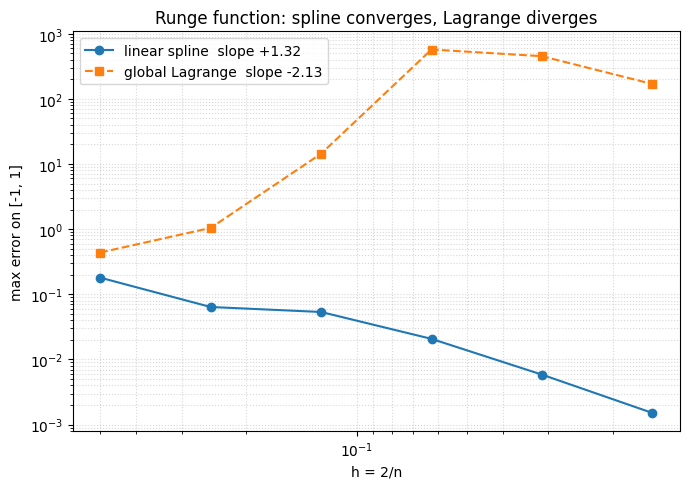

In [3]:
# --- 그림 1: 수렴 vs 발산 ---
fig, ax = plt.subplots(figsize=(7, 5))
ax.loglog(h, E_S1, "o-", label=f"linear spline  slope {slope_S1:+.2f}")
ax.loglog(h, E_pn, "s--", label=f"global Lagrange  slope {slope_pn:+.2f}")
ax.set_xlabel("h = 2/n")
ax.set_ylabel("max error on [-1, 1]")
ax.set_title("Runge function: spline converges, Lagrange diverges")
ax.invert_xaxis()
ax.legend(); ax.grid(True, which="both", ls=":", alpha=0.5)
plt.tight_layout(); plt.show()

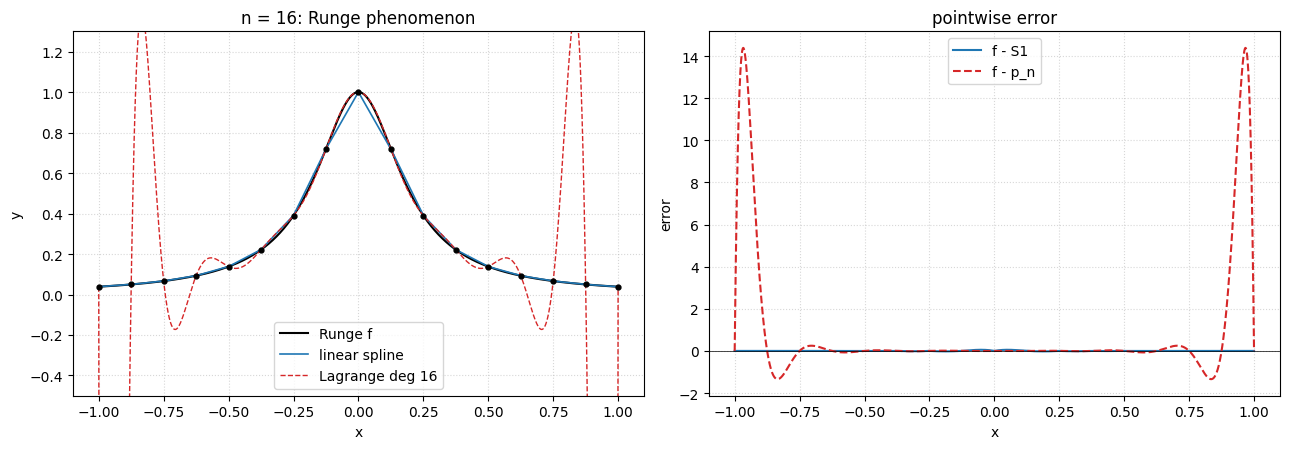

In [4]:
# --- 그림 2: n = 16 사례 시각화 ---
n_show = 16
t = np.linspace(a, b, n_show + 1)
y = f(t)
coefs = np.polyfit(t, y, n_show)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
ax = axes[0]
ax.plot(X, fX, "k-", lw=1.5, label="Runge f")
ax.plot(X, S1(t, y, X), "C0-", lw=1.2, label="linear spline")
ax.plot(X, np.polyval(coefs, X), "C3--", lw=1.0, label=f"Lagrange deg {n_show}")
ax.plot(t, y, "ko", ms=3.5)
ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_ylim(-0.5, 1.3)
ax.set_title(f"n = {n_show}: Runge phenomenon")
ax.legend(); ax.grid(True, ls=":", alpha=0.5)

ax = axes[1]
ax.plot(X, fX - S1(t, y, X), "C0-", label="f - S1")
ax.plot(X, fX - np.polyval(coefs, X), "C3--", label="f - p_n")
ax.axhline(0, color="k", lw=0.5)
ax.set_xlabel("x"); ax.set_ylabel("error")
ax.set_title("pointwise error")
ax.legend(); ax.grid(True, ls=":", alpha=0.5)
plt.tight_layout(); plt.show()

In [5]:
# --- 적응 노드: rho(x) ∝ sqrt(|f''(x)|) 의 누적분포 ---
def adaptive_knots(n, a, b, density_fn, n_grid=4001):
    xs = np.linspace(a, b, n_grid)
    rho = density_fn(xs)
    # 안전한 lower bound (어디서나 노드가 있어야 함)
    rho = np.maximum(rho, 1e-3 * rho.max())
    cdf = np.concatenate([[0.0], np.cumsum(0.5 * (rho[:-1] + rho[1:]) * np.diff(xs))])
    cdf /= cdf[-1]
    targets = np.linspace(0, 1, n + 1)
    t = np.interp(targets, cdf, xs)
    t[0], t[-1] = a, b
    return t

density = lambda x: np.sqrt(np.abs(fpp(x)) + 1e-12)

ns2 = [8, 16, 32, 64, 128]
E_uniform, E_adapt = [], []
for n in ns2:
    tu = np.linspace(a, b, n + 1); yu = f(tu)
    ta = adaptive_knots(n, a, b, density); ya = f(ta)
    E_uniform.append(np.max(np.abs(fX - S1(tu, yu, X))))
    E_adapt.append(  np.max(np.abs(fX - S1(ta, ya, X))))

df2 = pd.DataFrame({
    "n"            : ns2,
    "E uniform"    : E_uniform,
    "E adaptive"   : E_adapt,
    "ratio U/A"    : np.array(E_uniform) / np.array(E_adapt),
})
df2

,n,E uniform,E adaptive,ratio U/A
0,8,6.3901e-02,3.3128e-02,1.9289e+00
1,16,5.3552e-02,8.0134e-03,6.6828e+00
2,32,2.0701e-02,1.9818e-03,1.0446e+01
3,64,5.8504e-03,5.0249e-04,1.1643e+01
4,128,1.5097e-03,1.2361e-04,1.2213e+01


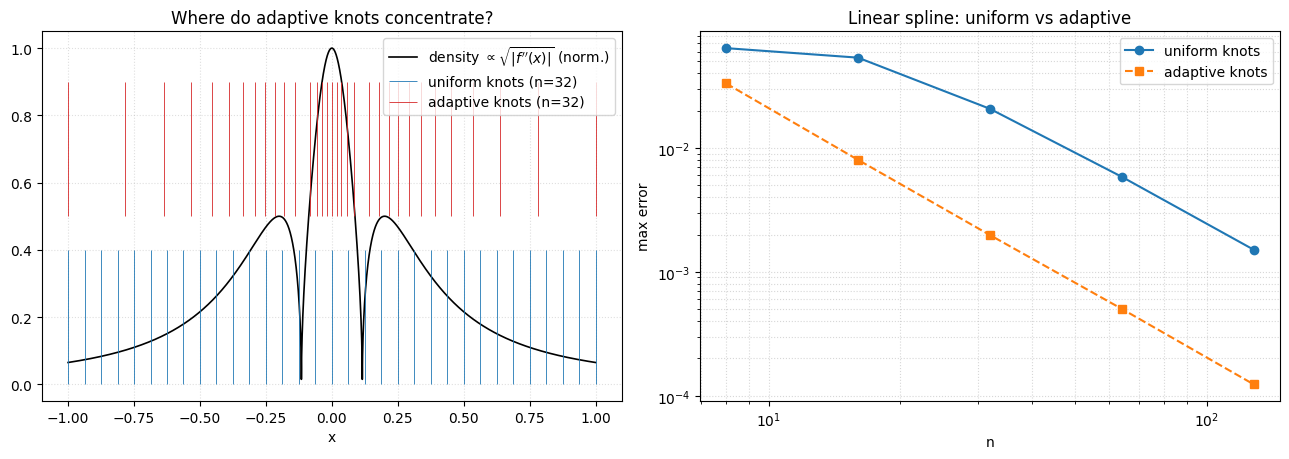

In [6]:
# --- 그림 3: 노드 분포 & 오차 비교 ---
fig, axes = plt.subplots(1, 2, figsize=(13, 4.7))

# (a) 노드가 어디로 모이는가
n_demo = 32
tu = np.linspace(a, b, n_demo + 1)
ta = adaptive_knots(n_demo, a, b, density)

ax = axes[0]
ax.plot(X, density(X) / density(X).max(), "k-", lw=1.2, label=r"density $\propto \sqrt{|f''(x)|}$ (norm.)")
ax.vlines(tu, 0, 0.4, color="C0", lw=0.6, label=f"uniform knots (n={n_demo})")
ax.vlines(ta, 0.5, 0.9, color="C3", lw=0.6, label=f"adaptive knots (n={n_demo})")
ax.set_xlabel("x"); ax.set_title("Where do adaptive knots concentrate?")
ax.legend(loc="upper right"); ax.grid(True, ls=":", alpha=0.4)

# (b) 정확도 비교
ax = axes[1]
ax.loglog(ns2, E_uniform, "o-",  label="uniform knots")
ax.loglog(ns2, E_adapt,   "s--", label="adaptive knots")
ax.set_xlabel("n"); ax.set_ylabel("max error")
ax.set_title("Linear spline: uniform vs adaptive")
ax.legend(); ax.grid(True, which="both", ls=":", alpha=0.5)
plt.tight_layout(); plt.show()

## 4. 결과 해석

1. **Runge 현상의 시각.** 같은 16 개 균등 노드에서 전역 Lagrange 는 $x = \pm 1$ 부근에서 $\pm 1$ 을 넘나드는
   진동을 보인다. 노드 수를 더 늘리면 *오차가 증가* — 표에서 기울기가 *음수* 로 나오는 이유. 1차 spline 은
   같은 노드에서 *지역적으로* $h^2$ 로 수렴한다.
2. **적응 노드의 이득.** $|f''|$ 가 큰 원점 부근에 노드가 *더 모이도록* 만들면, 같은 $n$ 에서 최대 오차가
   *수배* 줄어든다 (표의 `ratio U/A`). 균등 분포는 끝점에서 *낭비* 되는 자유도를 *비싼 곳* 으로 옮기는 셈.
3. **함수가 *어디서 어려운지* 를 함수가 가르친다.** Day 22 적응형 적분의 *지역 오차 추정 → 분할* 의 사고를,
   이번엔 *함수 표현 자체* 의 노드 배치로 옮긴 것. cubic spline (다음 절) 에서는 *어디에* 와 더불어
   *어떻게* (자유도 잠금) 의 두 차원이 동시에 작동한다.

### 결론
> **1차 spline = 지역성이 만든 *어떤 함수에서도 발산하지 않는* 안전망.**
> 노드를 *함수가 어려운 곳* 에 모으면 spline 의 $\mathcal O(h^2)$ 상수항을 추가로 절약할 수 있다.
> 같은 사고가 cubic spline 의 *knot 배치* 와 *적응형 cubature* 의 *지역 분할* 까지 일관되게 연결된다.

### 다음 절 (§6.2) 예고
2차 spline 의 *부호-교대 진폭 잔존* 을 *연립방정식 (tridiagonal)* 으로 잠그면 3차 cubic spline 이 나온다.
$C^2$ 부드러움 + 자유도 두 개의 *경계 조건* (natural / clamped / not-a-knot) 의 선택이 어떻게 정확도를
바꾸는지 — 그리고 *지역 오차 등배분* 의 사고가 cubic spline 의 knot 배치에서 한층 더 강력해진다.